# Stock Market Simulator Notebook

This notebook replicates the functionality of the stock market simulator web app. It allows you to simulate investments in various indices with monthly contributions, dividend reinvestment, and inflation adjustments.

## Features:
- Fetch historical data for indices using yfinance
- Simulate monthly investments
- Reinvest dividends
- Adjust for inflation
- Calculate CAGR and other metrics
- Visualize results

In [1]:
# Import required libraries
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

## Parameters

Set the simulation parameters below. For European markets like EuroStoxx50, set currency to 'EUR' to see results in Euros with appropriate inflation adjustment.

In [2]:
# Simulation parameters
tickers = ['SPY', 'URTH', 'FEZ', '^STOXX50E', 'QQQ', 'DIA']  # Indices to simulate
start_date = '2010-01-01'
end_date = '2025-12-01'
initial_investment = 10000  # Initial lump sum (in USD for simplicity)
monthly_contribution = 0  # Monthly contribution (in USD for simplicity)
reinvest_dividends = True  # Whether to reinvest dividends
inflation_adjusted = True  # Adjust for inflation

# Currency mapping for tickers (native currency of each market)
TICKER_CURRENCIES = {
    'SPY': 'USD',      # S&P 500 ETF
    'URTH': 'USD',     # MSCI World ETF (USD denominated)
    'FEZ': 'USD',      # EuroStoxx50 ETF (trades in USD)
    '^STOXX50E': 'EUR', # EuroStoxx50 index (priced in EUR)
    'QQQ': 'USD',      # NASDAQ-100 ETF
    'DIA': 'USD'       # Dow Jones ETF
}

# CPI tickers for inflation adjustment
CPI_TICKERS = {
    'USD': 'CPIAUCSL',              # US CPI
    'EUR': 'CP0000EZ19M086NEST'     # Euro Area CPI
}

# FX ticker for currency conversion (when needed for comparison)
fx_ticker = 'EURUSD=X'

## Fetch Market Data

Fetch historical prices and dividends for the selected tickers.

In [3]:
def fetch_data(ticker, start, end):
    """Fetch data for a ticker in its native currency"""
    data = yf.Ticker(ticker).history(start=start, end=end, actions=True)
    data = data.tz_localize(None)
    monthly = data.resample('MS').agg({
        'Close': 'last',
        'Dividends': 'sum'
    }).fillna(0)
    monthly['DividendYield'] = monthly['Dividends'] / monthly['Close']
    return monthly

# Fetch FX data for potential conversions
fx_data = yf.Ticker(fx_ticker).history(start=start_date, end=end_date)
fx_data = fx_data.tz_localize(None)
fx_monthly = fx_data.resample('MS').last()['Close']

# Fetch data for all tickers (in their native currencies)
market_data = {}
ticker_currencies = {}
for ticker in tickers:
    print(f"Fetching data for {ticker}...")
    market_data[ticker] = fetch_data(ticker, start_date, end_date)
    ticker_currencies[ticker] = TICKER_CURRENCIES.get(ticker, 'USD')  # Default to USD
    print(f"  {ticker}: {ticker_currencies[ticker]}")

# Fetch CPI data for each currency
cpi_data = {}
for currency, cpi_ticker in CPI_TICKERS.items():
    if inflation_adjusted:
        cpi_url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={cpi_ticker}"
        cpi_df = pd.read_csv(cpi_url, index_col=0, parse_dates=True)
        cpi_monthly = cpi_df.resample('MS').last()
        cpi_data[currency] = cpi_monthly.loc[start_date:end_date]
        print(f"Fetched {currency} CPI data")

print("Data fetching complete!")

Fetching data for SPY...
  SPY: USD
Fetching data for URTH...
  URTH: USD
Fetching data for FEZ...
  FEZ: USD
Fetching data for ^STOXX50E...
  ^STOXX50E: EUR
Fetching data for QQQ...
  QQQ: USD
Fetching data for DIA...
  DIA: USD
Fetched USD CPI data
Fetched EUR CPI data
Data fetching complete!


## Simulation Function

Define the simulation logic.

In [4]:
def simulate_investment(ticker, data, initial, monthly, reinvest_div, currency):
    """Simulate investment in the ticker's native currency"""
    timeline = []
    shares = 0
    cash = 0
    total_invested = 0
    
    for idx, row in data.iterrows():
        # Initial investment at start
        if len(timeline) == 0 and initial > 0:
            shares += initial / row['Close']
            total_invested += initial
        
        # Monthly contribution
        if monthly > 0:
            shares += monthly / row['Close']
            total_invested += monthly
        
        # Dividends
        dividend = shares * row['Close'] * row['DividendYield']
        if reinvest_div:
            shares += dividend / row['Close']
        else:
            cash += dividend
        
        value = shares * row['Close'] + cash
        timeline.append({
            'date': idx,
            'value': value,
            'invested': total_invested
        })
    
    return pd.DataFrame(timeline)

# Run simulations
results = {}
for ticker in tickers:
    currency = ticker_currencies[ticker]
    print(f"Simulating {ticker} in {currency}...")
    results[ticker] = simulate_investment(ticker, market_data[ticker], initial_investment, monthly_contribution, reinvest_dividends, currency)

print("Simulations complete!")

Simulating SPY in USD...
Simulating URTH in USD...
Simulating FEZ in USD...
Simulating ^STOXX50E in EUR...
Simulating QQQ in USD...
Simulating DIA in USD...
Simulations complete!


## Calculate Metrics

Calculate CAGR and other performance metrics.

In [5]:
def calculate_metrics(df, ticker, cpi_data_dict, ticker_currency, inflation_adj=False):
    if len(df) < 2:
        return {}
    
    start_value = df.iloc[0]['value']
    end_value = df.iloc[-1]['value']
    total_invested = df.iloc[-1]['invested']
    start_date = df.iloc[0]['date']
    end_date = df.iloc[-1]['date']
    years = (end_date - start_date).days / 365.25
    
    # Nominal CAGR and return
    nominal_cagr = (end_value / start_value) ** (1 / years) - 1 if start_value > 0 else 0
    nominal_return = (end_value - total_invested) / total_invested if total_invested > 0 else 0
    
    # Real (inflation-adjusted) values using appropriate CPI
    cpi_data = cpi_data_dict.get(ticker_currency)
    if inflation_adj and cpi_data is not None:
        # Align CPI with portfolio dates
        cpi_aligned = cpi_data.loc[start_date:end_date]
        if len(cpi_aligned) > 0:
            cpi_start = cpi_aligned.iloc[0, 0]
            cpi_end = cpi_aligned.iloc[-1, 0]
            
            # Express everything in end-of-period currency for real return calculation
            real_value = end_value  # Already in end-date currency
            real_invested = total_invested * (cpi_end / cpi_start)  # Inflate investments to end-date currency
            
            # Real return in end-of-period currency
            real_return = (real_value - real_invested) / real_invested if real_invested > 0 else 0
            
            # Real CAGR: compare inflation-adjusted end value to start value
            adjusted_end_value = end_value * (cpi_start / cpi_end)  # Convert to start-date purchasing power
            real_cagr = (adjusted_end_value / start_value) ** (1 / years) - 1 if start_value > 0 else 0
        else:
            real_cagr = nominal_cagr
            real_return = nominal_return
            adjusted_end_value = end_value
    else:
        real_cagr = nominal_cagr
        real_return = nominal_return
        adjusted_end_value = end_value
    
    # Max drawdown
    df_copy = df.copy()
    df_copy['peak'] = df_copy['value'].cummax()
    df_copy['drawdown'] = (df_copy['value'] - df_copy['peak']) / df_copy['peak']
    max_drawdown = df_copy['drawdown'].min()
    
    return {
        'Currency': ticker_currency,
        'Final Value (Nominal)': end_value,
        'Final Value (Real)': adjusted_end_value,
        'Total Invested': total_invested,
        'CAGR (Nominal)': nominal_cagr,
        'CAGR (Real)': real_cagr,
        'Total Return (Nominal)': nominal_return,
        'Total Return (Real)': real_return,
        'Max Drawdown': max_drawdown
    }

# Calculate metrics for each ticker
metrics = {}
for ticker, df in results.items():
    currency = ticker_currencies[ticker]
    metrics[ticker] = calculate_metrics(df, ticker, cpi_data, currency, inflation_adjusted)

# Display metrics
metrics_df = pd.DataFrame(metrics).T
print("\n=== Investment Simulation Results (Native Currencies) ===\n")
print(metrics_df.to_string())
print("\n" + "="*80)
print("EXPLANATION:")
print("="*80)
print("Each ticker is simulated in its native market currency:")
print("- USD tickers (SPY, QQQ, DIA, URTH, FEZ): Results in USD with US inflation")
print("- EUR tickers (^STOXX50E): Results in EUR with Euro Area inflation")
print("\nNominal Return: Raw gain in the ticker's currency")
print("Real Return: Gain after adjusting for local inflation")
print("\nThis allows fair comparison within each market, accounting for local economic conditions.")


=== Investment Simulation Results (Native Currencies) ===

          Currency Final Value (Nominal) Final Value (Real) Total Invested CAGR (Nominal) CAGR (Real) Total Return (Nominal) Total Return (Real) Max Drawdown
SPY            USD         117504.670075        78618.16228          10000       0.168379    0.139097              10.750467            6.861816     -0.22992
URTH           USD          62761.622249       43990.652694          10000       0.141985    0.113024               5.276162            3.399065     -0.24757
FEZ            USD           52479.92543       35112.436734          10000       0.110387    0.082557               4.247993            2.511244    -0.330226
^STOXX50E      EUR          20412.375847         14460.0165          10000       0.046099    0.023567               1.041238            0.446002    -0.296755
QQQ            USD         193078.960662      129182.210822          10000       0.205608    0.175392              18.307896           11.918221    -0

In [6]:
# Interactive plots with Plotly: net investment & total gain, grouped by currency
import plotly.express as px

# build long-format frame including net invested
all_dfs = []
for ticker, df in results.items():
    # determine currency per ticker using mapping or prefix
    curr = 'EUR' if ticker.startswith('^') or ticker in ['FEZ'] else 'USD'
    temp = df.copy()
    temp['ticker'] = ticker
    temp['currency'] = curr
    temp['net_invested'] = temp['invested']
    all_dfs.append(temp)
all_long = pd.concat(all_dfs)

# nominal grouped plots
for curr in all_long['currency'].unique():
    subset = all_long[all_long['currency'] == curr]
    fig = px.line(subset, x='date', y='value', color='ticker',
                  title=f'Nominal Portfolio Growth ({curr})',
                  labels={'value': f'Value ({curr})'})
    fig.add_scatter(x=subset['date'], y=subset['net_invested'],
                    mode='lines', name='Net Invested', line=dict(dash='dash'))
    fig.show()

# real growth single plot
if inflation_adjusted and cpi_monthly is not None:
    real_list = []
    for ticker, df in results.items():
        temp = df.copy()
        start = temp.iloc[0]['date']; end = temp.iloc[-1]['date']
        cpi_sub = cpi_monthly.loc[start:end].squeeze()
        if len(cpi_sub) > 0:
            cpi0 = cpi_sub.iloc[0]
            cpi_filled = cpi_sub.reindex(temp['date'], method='ffill')
            temp['value_real'] = temp['value'] * (cpi0 / cpi_filled.values)
        else:
            temp['value_real'] = temp['value']
        temp['ticker'] = ticker
        temp['net_invested'] = temp['invested']
        real_list.append(temp)
    real_long = pd.concat(real_list)
    fig2 = px.line(real_long, x='date', y='value_real', color='ticker',
                   title='Real (Inflation-Adjusted) Growth (All Currencies)',
                   labels={'value_real': f'Value ({currency} units)'} )
    fig2.add_scatter(x=real_long['date'], y=real_long['net_invested'],
                     mode='lines', name='Net Invested', line=dict(dash='dash'))
    fig2.show()
else:
    print('Inflation-adjusted data unavailable, real plot skipped')

# additional macro plots: CPI and FX
# fetch both CPI series for comparison
if inflation_adjusted:
    # US CPI
    us_url = 'https://fred.stlouisfed.org/graph/fredgraph.csv?id=CPIAUCSL'
    us_cpi = pd.read_csv(us_url, index_col=0, parse_dates=True)
    us_cpi = us_cpi.resample('MS').last()
    # Euro area CPI code used earlier
    eur_url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={cpi_ticker}"
    eur_cpi = pd.read_csv(eur_url, index_col=0, parse_dates=True)
    eur_cpi = eur_cpi.resample('MS').last()
    # combine
    cpi_plot = pd.DataFrame({
        'US CPI': us_cpi.squeeze(),
        'Euro CPI': eur_cpi.squeeze()
    }).dropna()
    fig3 = px.line(cpi_plot, x=cpi_plot.index, y=cpi_plot.columns,
                   title='CPI Comparison (US vs Euro Area)')
    fig3.show()

# FX plot if available
if fx_monthly is not None:
    fig4 = px.line(x=fx_monthly.index, y=fx_monthly.values,
                   title='EUR/USD Exchange Rate',
                   labels={'x': 'Date', 'y': 'EUR per USD'})
    fig4.show()


In [7]:
# Monte Carlo forecast based on historical monthly returns
import numpy as np

horizon_years = 10
simulations = 1000

forecast_df = []
for ticker, df in results.items():
    df2 = df.copy()
    df2['return'] = df2['value'].pct_change().fillna(0)
    mu = df2['return'].mean()
    sigma = df2['return'].std()
    last_val = df2['value'].iloc[-1]
    steps = horizon_years * 12
    # simulate
    paths = np.zeros((steps, simulations))
    for i in range(simulations):
        prices = [last_val]
        for _ in range(steps):
            shock = np.random.normal(mu, sigma)
            prices.append(prices[-1] * (1 + shock))
        paths[:, i] = prices[1:]
    # compute statistics for each month
    months = pd.date_range(start=df2['date'].iloc[-1] + pd.offsets.MonthBegin(1), periods=steps, freq='MS')
    median = np.median(paths, axis=1)
    p10 = np.percentile(paths, 10, axis=1)
    p90 = np.percentile(paths, 90, axis=1)
    # store for plotting
    tmp = pd.DataFrame({
        'date': months,
        'ticker': ticker,
        'median': median,
        'p10': p10,
        'p90': p90
    })
    forecast_df.append(tmp)

forecast_long = pd.concat(forecast_df)

# plot forecast
import plotly.graph_objects as go
fig = go.Figure()
for ticker in forecast_long['ticker'].unique():
    sub = forecast_long[forecast_long['ticker'] == ticker]
    fig.add_trace(go.Scatter(x=sub['date'], y=sub['median'], mode='lines', name=f'{ticker} median'))
    fig.add_trace(go.Scatter(x=sub['date'], y=sub['p10'], mode='lines', name=f'{ticker} 10th', line=dict(dash='dash')))
    fig.add_trace(go.Scatter(x=sub['date'], y=sub['p90'], mode='lines', name=f'{ticker} 90th', line=dict(dash='dash')))
fig.update_layout(title=f'Monte Carlo Forecast ({horizon_years} years, {simulations} sims)',
                  xaxis_title='Date', yaxis_title=f'Value ({currency})')
fig.show()

In [8]:
# Monte Carlo forecast based on inflation-adjusted returns
import numpy as np

horizon_years = 10
simulations = 1000

forecast_df = []
for ticker, df in results.items():
    # Get currency for this ticker
    currency = ticker_currencies[ticker]
    cpi_data_curr = cpi_data.get(currency)
    
    # Compute inflation-adjusted values
    df_real = df.copy()
    if inflation_adjusted and cpi_data_curr is not None:
        start_date = df_real.iloc[0]['date']
        end_date = df_real.iloc[-1]['date']
        cpi_subset = cpi_data_curr.loc[start_date:end_date].squeeze()
        if len(cpi_subset) > 0:
            cpi_start = cpi_subset.iloc[0]
            cpi_filled = cpi_subset.reindex(df_real['date'], method='ffill')
            df_real['value_real'] = df_real['value'] * (cpi_start / cpi_filled.values)
        else:
            df_real['value_real'] = df_real['value']
    else:
        df_real['value_real'] = df_real['value']
    
    # Compute returns from inflation-adjusted values
    df_real['return'] = df_real['value_real'].pct_change().fillna(0)
    mu = df_real['return'].mean()
    sigma = df_real['return'].std()
    last_val = df_real['value_real'].iloc[-1]
    steps = horizon_years * 12
    
    # Monte Carlo simulation
    paths = np.zeros((steps, simulations))
    for i in range(simulations):
        prices = [last_val]
        for _ in range(steps):
            shock = np.random.normal(mu, sigma)
            prices.append(prices[-1] * (1 + shock))
        paths[:, i] = prices[1:]
    
    # Compute statistics for each month
    months = pd.date_range(start=df_real['date'].iloc[-1] + pd.offsets.MonthBegin(1), periods=steps, freq='MS')
    median = np.median(paths, axis=1)
    p10 = np.percentile(paths, 10, axis=1)
    p90 = np.percentile(paths, 90, axis=1)
    
    # Store for plotting
    tmp = pd.DataFrame({
        'date': months,
        'ticker': ticker,
        'median': median,
        'p10': p10,
        'p90': p90
    })
    forecast_df.append(tmp)

forecast_long = pd.concat(forecast_df)

# Plot forecast (inflation-adjusted)
import plotly.graph_objects as go
fig = go.Figure()
for ticker in forecast_long['ticker'].unique():
    sub = forecast_long[forecast_long['ticker'] == ticker]
    fig.add_trace(go.Scatter(x=sub['date'], y=sub['median'], mode='lines', name=f'{ticker} median'))
    fig.add_trace(go.Scatter(x=sub['date'], y=sub['p10'], mode='lines', name=f'{ticker} 10th', line=dict(dash='dash')))
    fig.add_trace(go.Scatter(x=sub['date'], y=sub['p90'], mode='lines', name=f'{ticker} 90th', line=dict(dash='dash')))
fig.update_layout(title=f'Monte Carlo Forecast - Real Returns ({horizon_years} years, {simulations} sims)',
                  xaxis_title='Date', yaxis_title='Value (Inflation-Adjusted)')
fig.show()

## Visualize Results

Plot the investment growth over time.

## Understanding Nominal vs. Real Returns

**Key Concept**: Inflation erodes your purchasing power. Real returns account for this.

### Concrete Example:
- **Year 0**: You invest $10,000 (CPI = 200)
- **Year 5**: Your portfolio is worth $50,000 (CPI = 260)

**Nominal Return**: ($50,000 - $10,000) / $10,000 = **400%**
- This is your raw dollar gain

**Real Return**: Due to inflation, your $10,000 would now cost $13,000 to buy the same basket of goods
- Real gain: ($50,000 - $13,000) / $13,000 = **285%**
- You still gained significantly, but inflation ate into your returns

The difference (400% - 285% = 115%) represents purchasing power lost to inflation.


## Cross-Market Comparison (USD Basis)

To compare performance across different markets, we can convert all results to USD using the final EUR/USD exchange rate. This shows how each investment would have performed if measured in the same currency.

**Note**: This is for comparison purposes only - actual returns depend on when you convert currencies and transaction costs.

In [9]:
# Cross-market comparison in USD
print("\n=== Cross-Market Comparison (All in USD) ===\n")

comparison_data = []
final_fx_rate = fx_monthly.iloc[-1]  # Final EUR/USD rate

for ticker, metric in metrics.items():
    currency = metric['Currency']
    final_value_usd = metric['Final Value (Nominal)']
    
    # Convert EUR to USD for comparison
    if currency == 'EUR':
        final_value_usd = final_value_usd * final_fx_rate
    
    comparison_data.append({
        'Ticker': ticker,
        'Currency': currency,
        'Final Value (USD)': final_value_usd,
        'CAGR (Nominal)': metric['CAGR (Nominal)'],
        'CAGR (Real)': metric['CAGR (Real)']
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))
print(f"\nExchange Rate Used: 1 EUR = {final_fx_rate:.4f} USD")
print("Note: EUR values converted to USD for comparison using final exchange rate.")


=== Cross-Market Comparison (All in USD) ===

   Ticker Currency  Final Value (USD)  CAGR (Nominal)  CAGR (Real)
      SPY      USD      117504.670075        0.168379     0.139097
     URTH      USD       62761.622249        0.141985     0.113024
      FEZ      USD       52479.925430        0.110387     0.082557
^STOXX50E      EUR       23678.053567        0.046099     0.023567
      QQQ      USD      193078.960662        0.205608     0.175392
      DIA      USD      100205.707495        0.156686     0.127697

Exchange Rate Used: 1 EUR = 1.1600 USD
Note: EUR values converted to USD for comparison using final exchange rate.


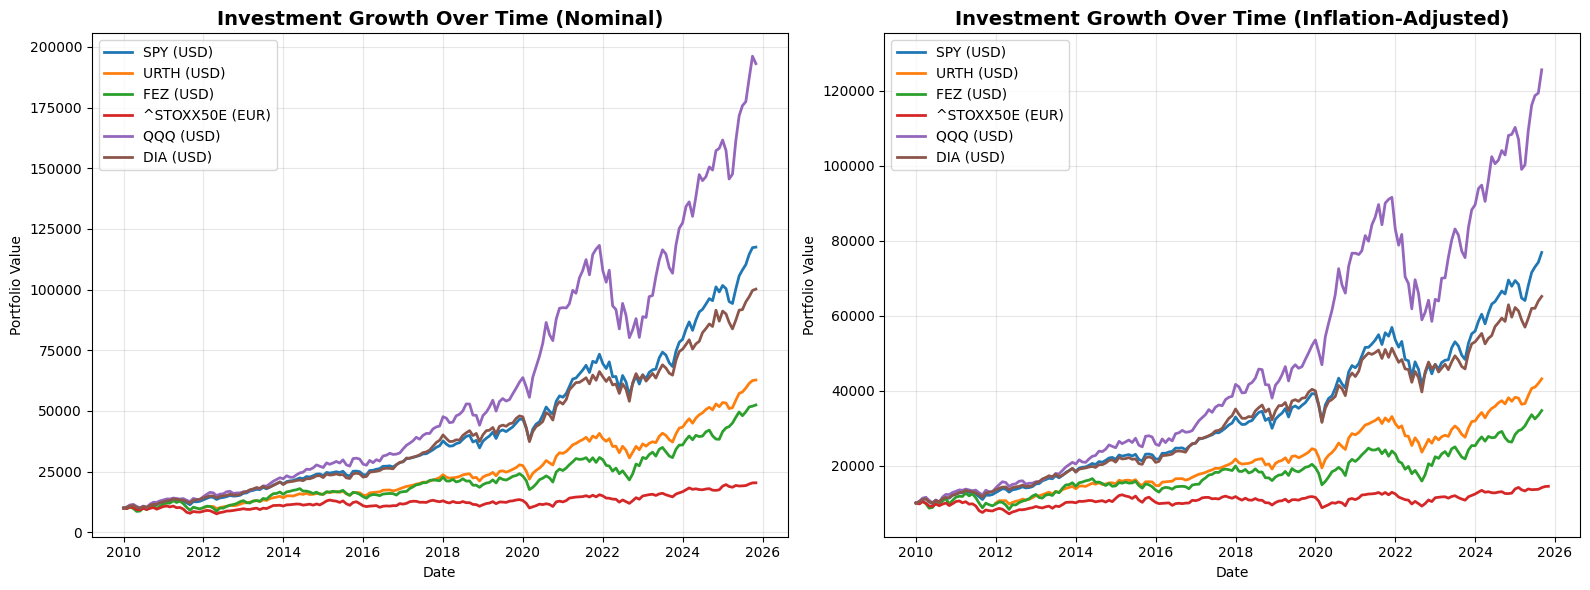

In [10]:
# Plot results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Nominal values
for ticker, df in results.items():
    currency = ticker_currencies[ticker]
    label = f"{ticker} ({currency})"
    axes[0].plot(df['date'], df['value'], label=label, linewidth=2)

axes[0].set_title('Investment Growth Over Time (Nominal)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Portfolio Value')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].ticklabel_format(style='plain', axis='y')

# Real (inflation-adjusted) values
if inflation_adjusted:
    for ticker, df in results.items():
        currency = ticker_currencies[ticker]
        cpi_data_curr = cpi_data.get(currency)
        
        if cpi_data_curr is not None:
            # Create CPI series aligned with portfolio dates
            start_date = df.iloc[0]['date']
            end_date = df.iloc[-1]['date']
            cpi_subset = cpi_data_curr.loc[start_date:end_date].squeeze()
            
            if len(cpi_subset) > 0:
                cpi_start = cpi_subset.iloc[0]
                # Forward fill to handle missing dates and align with portfolio
                cpi_filled = cpi_subset.reindex(df['date'], method='ffill')
                real_values = df['value'] * (cpi_start / cpi_filled.values)
                label = f"{ticker} ({currency})"
                axes[1].plot(df['date'], real_values, label=label, linewidth=2)
    
    axes[1].set_title('Investment Growth Over Time (Inflation-Adjusted)', fontsize=14, fontweight='bold')
else:
    for ticker, df in results.items():
        currency = ticker_currencies[ticker]
        label = f"{ticker} ({currency})"
        axes[1].plot(df['date'], df['value'], label=label, linewidth=2)
    axes[1].set_title('Investment Growth Over Time (No Inflation Adjustment)', fontsize=14, fontweight='bold')

axes[1].set_xlabel('Date')
axes[1].set_ylabel('Portfolio Value')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

## Summary

This notebook provides a sophisticated stock market simulator that handles multiple currencies appropriately.

Key features implemented:
- Historical data fetching in native currencies
- Currency-aware investment simulation
- Local inflation adjustment (US CPI for USD markets, Euro CPI for EUR markets)
- Performance metrics calculation in appropriate currencies
- Side-by-side visualization with currency labels

### Currency Handling:
- **USD Markets**: SPY, QQQ, DIA, URTH, FEZ (US ETFs trade in USD)
- **EUR Markets**: ^STOXX50E (European index priced in EUR)
- **Inflation Adjustment**: Uses appropriate regional CPI data
- **Fair Comparison**: Results reflect true market performance in each region

### Understanding the Results:
- **Nominal CAGR**: Raw growth rate in the ticker's native currency
- **Real CAGR**: Growth rate adjusted for local inflation
- **Final Value**: Portfolio value in the ticker's currency
- **Currency Column**: Shows which currency each result is in

This approach provides accurate, apples-to-apples comparisons within each market while accounting for local economic conditions. For cross-market comparisons, you can manually convert using current exchange rates.

For more advanced features like forecasting or multiple contribution schedules, the web app provides additional functionality.